In [3]:
from pathlib import Path

import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in (CWD, *CWD.parents)
     if (candidate / 'analyses').is_dir() and (candidate / 'bases').is_dir()),
    None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Nao foi possivel localizar a raiz do projeto.')

DATA_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '01_dados'
OUTPUT_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '02_modelos' / 'Random_Forest'
RANDOM_STATE = 42
TRAIN_RATIO = 0.70

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#ccccee',
    'xtick.color': '#aaaacc',
    'ytick.color': '#aaaacc',
    'text.color': '#e0e0ff',
    'grid.color': '#2a2a4a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.size': 10
})

# Random Forest — 01: Otimização de Hiperparâmetros
**Grupo 1 | Séries Temporais**

O notebook otimiza um Random Forest Regressor para prever o fechamento diário do Bitcoin a partir das features já preparadas. A seleção usa somente o treino (70% iniciais), com `TimeSeriesSplit` e MAE; o teste final não participa da escolha.

A busca aleatória avalia 24 combinações, com `random_state=42`. A configuração ótima é ajustada novamente sobre todo o treino, e a importância das features é calculada nesse ajuste. Resultados e gráficos são exibidos no notebook, sem criar arquivos auxiliares.

Hiperparâmetros explorados: `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf` e `max_features`.

Base de treino: 1996 observacoes | 2018-11-20 a 2024-05-07
Features: 51 | Alvo: target (fechamento t+1)
Divisao treino/teste declarada: 70%/30%
Random state: 42
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Melhor configuracao selecionada por MAE_CV:
  n_estimators: 300
  min_samples_split: 2
  min_samples_leaf: 4
  max_features: 0.7
  max_depth: 8
  MAE_CV: USD 6,380.51 (± USD 9,132.42)
  R2_CV: 0.1564


,rank_test_mae,params,mae_cv_mean,mae_cv_std,r2_cv_mean
0,1,"{'n_estimators': 300, 'min_samples_split': 2, ...",6380.510435,9132.418289,0.156372
1,2,"{'n_estimators': 400, 'min_samples_split': 2, ...",6395.039579,9135.123436,0.154656
2,3,"{'n_estimators': 400, 'min_samples_split': 10,...",6395.846945,9125.610848,0.154745
3,4,"{'n_estimators': 200, 'min_samples_split': 2, ...",6403.562008,9134.145298,0.155400
4,5,"{'n_estimators': 300, 'min_samples_split': 10,...",6409.595612,9192.401716,0.151887
5,6,"{'n_estimators': 300, 'min_samples_split': 5, ...",6417.892061,9148.036520,0.148662
6,7,"{'n_estimators': 400, 'min_samples_split': 10,...",6421.476846,9145.633003,0.147314
7,8,"{'n_estimators': 400, 'min_samples_split': 2, ...",6422.160239,9146.017455,0.147574
8,9,"{'n_estimators': 400, 'min_samples_split': 5, ...",6422.571902,9141.730173,0.149731
9,10,"{'n_estimators': 200, 'min_samples_split': 10,...",6425.331911,9165.261784,0.152602



Top 10 features por importancia (ajuste no treino):


,importance
close_lag1,0.363343
log_close_lag1,0.348398
close_lag2,0.119309
close_ma7,0.038276
close_lag3,0.022299
close_lag7,0.015398
close_ma30,0.013751
log_close_lag7,0.013151
close_ma60,0.012544
close_ma90,0.011317


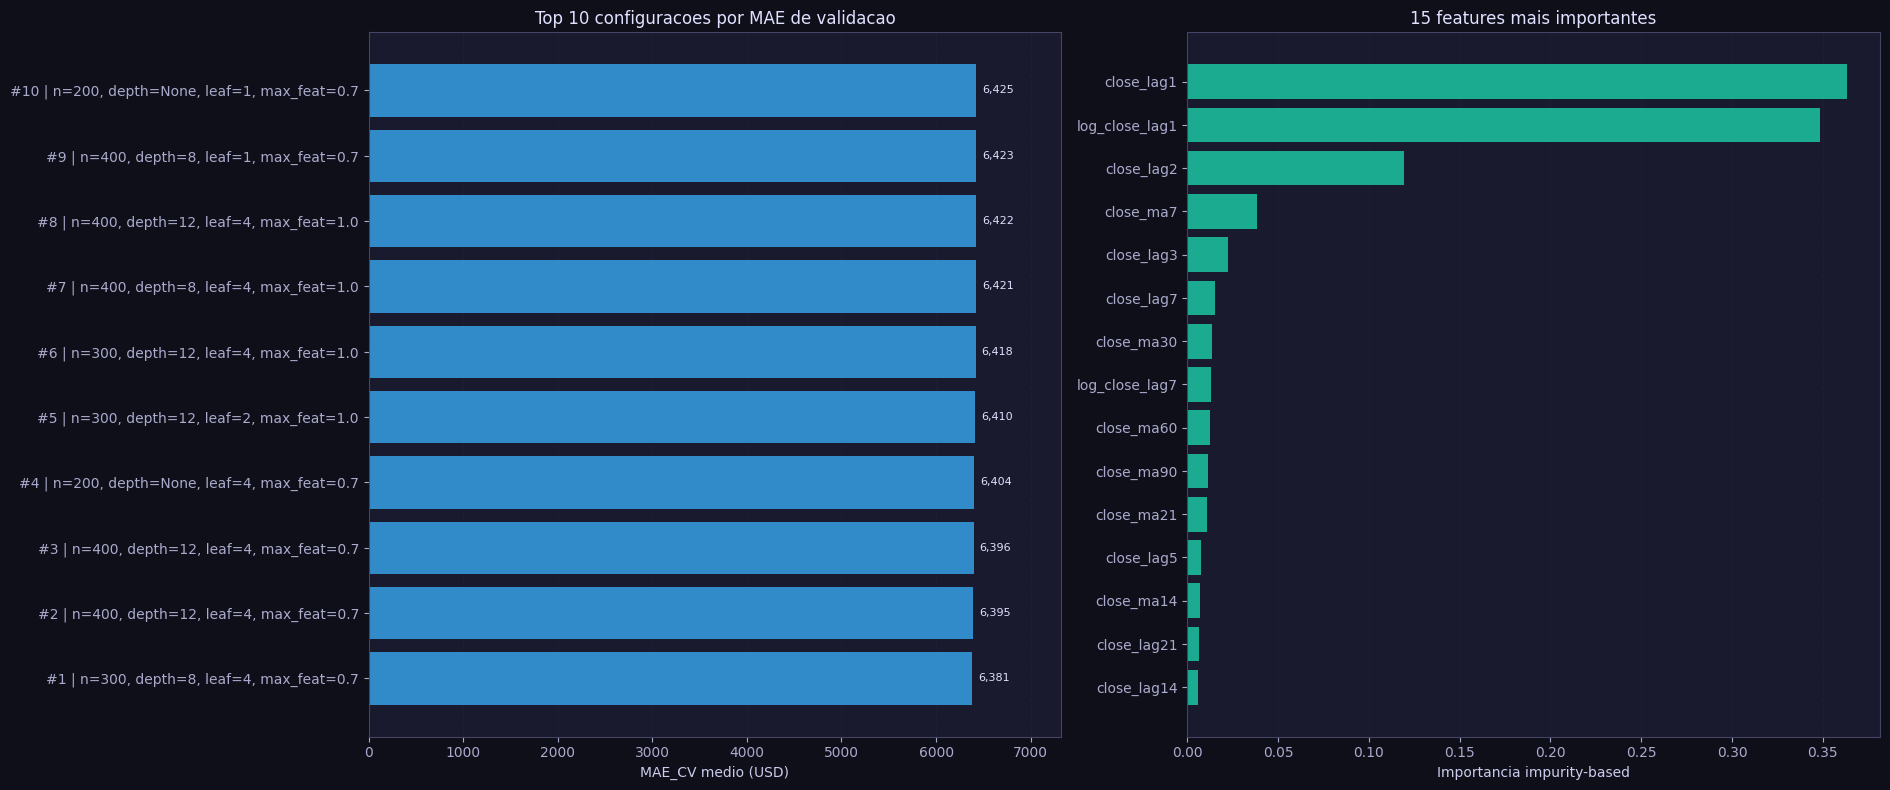


Configuracao final (em memoria; nenhum arquivo auxiliar criado):
{'modelo': 'Random_Forest', 'base': 'bitcoin', 'alvo': 'target', 'n_features': 51, 'n_train': 1996, 'data_corte': '2024-05-08', 'random_state': 42, 'train_ratio': 0.7, 'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 8, 'mae_cv': 6380.510434962252, 'mae_cv_std': 9132.41828930044, 'r2_cv': 0.1563716539211877, 'n_iter': 24, 'n_splits': 5, 'metodo_selecao': 'RandomizedSearchCV com TimeSeriesSplit; criterio MAE'}


In [4]:
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

warnings.filterwarnings('ignore')

# Carregamento do treino e metadados usando os caminhos pathlib da celula 1.
train_path = DATA_DIR / 'bitcoin_features_train.csv'
meta_path = DATA_DIR / 'feature_metadata.json'
train = pd.read_csv(train_path, parse_dates=['date']).sort_values('date').reset_index(drop=True)
with meta_path.open('r', encoding='utf-8') as file:
    meta = json.load(file)

FEATURE_COLS = meta['feature_cols']
target_col = meta['target_col']
X_train = train[FEATURE_COLS].astype(float)
y_train = train[target_col].astype(float)

if not np.isfinite(X_train.to_numpy()).all() or not np.isfinite(y_train.to_numpy()).all():
    raise ValueError('O treino contem valores ausentes ou nao finitos nas features/alvo.')
if not np.isclose(meta['train_ratio'], TRAIN_RATIO):
    raise ValueError('A proporcao do treino diverge do protocolo esperado de 70%.')

print(f"Base de treino: {len(train)} observacoes | {train['date'].min().date()} a {train['date'].max().date()}")
print(f'Features: {len(FEATURE_COLS)} | Alvo: {target_col} (fechamento t+1)')
print(f"Divisao treino/teste declarada: {meta['train_ratio']:.0%}/{1 - meta['train_ratio']:.0%}")
print(f'Random state: {RANDOM_STATE}')

# Busca aleatoria em folds cronologicos; o teste final nao e acessado.
param_distributions = {
    'n_estimators': [200, 300, 400],
    'max_depth': [None, 8, 12],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.7, 1.0]
}
cv = TimeSeriesSplit(n_splits=5)
scoring = {
    'mae': make_scorer(mean_absolute_error, greater_is_better=False),
    'r2': 'r2'
}
search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
    param_distributions=param_distributions,
    n_iter=24,
    scoring=scoring,
    refit='mae',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)
search.fit(X_train, y_train)

rf_grid = pd.DataFrame(search.cv_results_).sort_values('rank_test_mae').reset_index(drop=True)
rf_grid['mae_cv_mean'] = -rf_grid['mean_test_mae']
rf_grid['mae_cv_std'] = rf_grid['std_test_mae']
rf_grid['r2_cv_mean'] = rf_grid['mean_test_r2']
best_rf = search.best_params_
best_mae = -search.best_score_
best_row = rf_grid.iloc[0]

print('\nMelhor configuracao selecionada por MAE_CV:')
for name, value in best_rf.items():
    print(f'  {name}: {value}')
print(f"  MAE_CV: USD {best_mae:,.2f} (± USD {best_row['mae_cv_std']:,.2f})")
print(f"  R2_CV: {best_row['r2_cv_mean']:.4f}")
display(rf_grid[[
    'rank_test_mae', 'params', 'mae_cv_mean', 'mae_cv_std', 'r2_cv_mean'
]].head(10))

# O refit automatico usa todos os dados de treino para a melhor configuracao.
rf_final = search.best_estimator_
feature_importance = pd.Series(
    rf_final.feature_importances_, index=FEATURE_COLS, name='importance'
).sort_values(ascending=False)
print('\nTop 10 features por importancia (ajuste no treino):')
display(feature_importance.head(10).to_frame())

# Graficos com contraste legivel e valores de MAE identificados.
fig, axes = plt.subplots(1, 2, figsize=(19, 8), facecolor='#0f0f1a')
plot_df = rf_grid.head(10).sort_values('mae_cv_mean', ascending=True)
labels = [
    f"#{int(row.rank_test_mae)} | n={row.params['n_estimators']}, depth={row.params['max_depth']}, "
    f"leaf={row.params['min_samples_leaf']}, max_feat={row.params['max_features']}"
    for row in plot_df.itertuples()
]
bars = axes[0].barh(labels, plot_df['mae_cv_mean'], color='#3498db', alpha=0.9)
axes[0].set_title('Top 10 configuracoes por MAE de validacao', color='#e0e0ff')
axes[0].set_xlabel('MAE_CV medio (USD)')
axes[0].set_xlim(0, float(plot_df['mae_cv_mean'].max()) * 1.14)
axes[0].grid(axis='x', alpha=0.3)
axes[0].set_axisbelow(True)
for bar, value in zip(bars, plot_df['mae_cv_mean']):
    axes[0].text(
        value + float(plot_df['mae_cv_mean'].max()) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{value:,.0f}', va='center', fontsize=8, color='#e0e0ff'
    )

top_features = feature_importance.head(15).sort_values()
axes[1].barh(top_features.index, top_features.values, color='#1abc9c', alpha=0.9)
axes[1].set_title('15 features mais importantes', color='#e0e0ff')
axes[1].set_xlabel('Importancia impurity-based')
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_axisbelow(True)
plt.tight_layout()
plt.show()

# Configuracao mantida em memoria; nao cria arquivos auxiliares.
config_final = {
    'modelo': 'Random_Forest',
    'base': 'bitcoin',
    'alvo': target_col,
    'n_features': len(FEATURE_COLS),
    'n_train': int(len(X_train)),
    'data_corte': meta['data_corte'],
    'random_state': RANDOM_STATE,
    'train_ratio': TRAIN_RATIO,
    **best_rf,
    'mae_cv': float(best_mae),
    'mae_cv_std': float(best_row['mae_cv_std']),
    'r2_cv': float(best_row['r2_cv_mean']),
    'n_iter': search.n_iter,
    'n_splits': cv.n_splits,
    'metodo_selecao': 'RandomizedSearchCV com TimeSeriesSplit; criterio MAE'
}
print('\nConfiguracao final (em memoria; nenhum arquivo auxiliar criado):')
print(config_final)